<a href="https://colab.research.google.com/github/daniel2255555/Ai-Assignment/blob/main/TraditionalMachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Install dependencies
!pip install opencv-python-headless scikit-learn scikit-image matplotlib seaborn joblib kaggle

# Cell 2: Download FER2013 from Kaggle
# Upload your kaggle.json first, then:
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d msambare/fer2013
!unzip fer2013.zip -d fer2013/

Streaming output truncated to the last 5000 lines.
  inflating: fer2013/train/sad/Training_65242339.jpg  
  inflating: fer2013/train/sad/Training_65267116.jpg  
  inflating: fer2013/train/sad/Training_65275626.jpg  
  inflating: fer2013/train/sad/Training_6529266.jpg  
  inflating: fer2013/train/sad/Training_65329617.jpg  
  inflating: fer2013/train/sad/Training_65338712.jpg  
  inflating: fer2013/train/sad/Training_65338797.jpg  
  inflating: fer2013/train/sad/Training_65387162.jpg  
  inflating: fer2013/train/sad/Training_65404494.jpg  
  inflating: fer2013/train/sad/Training_65426218.jpg  
  inflating: fer2013/train/sad/Training_65430136.jpg  
  inflating: fer2013/train/sad/Training_65437377.jpg  
  inflating: fer2013/train/sad/Training_6545735.jpg  
  inflating: fer2013/train/sad/Training_65463385.jpg  
  inflating: fer2013/train/sad/Training_65473985.jpg  
  inflating: fer2013/train/sad/Training_65502829.jpg  
  inflating: fer2013/train/sad/Training_65505359.jpg  
  inflating: fer

In [2]:
import os, cv2, numpy as np
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler, LabelEncoder

EMOTIONS = ['angry','disgust','fear','happy','neutral','sad','surprise']
DATA_DIR = 'fer2013/train'

def extract_hog(img_gray):
    """Extract HOG features — the SVM's eyes."""
    features, _ = hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        visualize=True,
        block_norm='L2-Hys'
    )
    return features

X, y = [], []
for label in EMOTIONS:
    folder = os.path.join(DATA_DIR, label)
    for fname in os.listdir(folder)[:1000]:  # limit for speed
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (48, 48))
            X.append(extract_hog(img))
            y.append(label)

X = np.array(X)
y = np.array(y)
print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features each")

Dataset: 6436 samples, 4356 features each


Variance retained: 51.5%
LinearSVC report:
              precision    recall  f1-score   support

       angry       0.31      0.28      0.29       200
     disgust       0.40      0.27      0.32        88
        fear       0.23      0.10      0.14       200
       happy       0.42      0.58      0.48       200
     neutral       0.36      0.40      0.38       200
         sad       0.32      0.30      0.31       200
    surprise       0.45      0.60      0.51       200

    accuracy                           0.37      1288
   macro avg       0.35      0.36      0.35      1288
weighted avg       0.35      0.37      0.35      1288

RBF SVM report:
              precision    recall  f1-score   support

       angry       0.33      0.33      0.33       200
     disgust       0.82      0.36      0.50        88
        fear       0.25      0.22      0.24       200
       happy       0.47      0.56      0.51       200
     neutral       0.36      0.48      0.41       200
         sad       

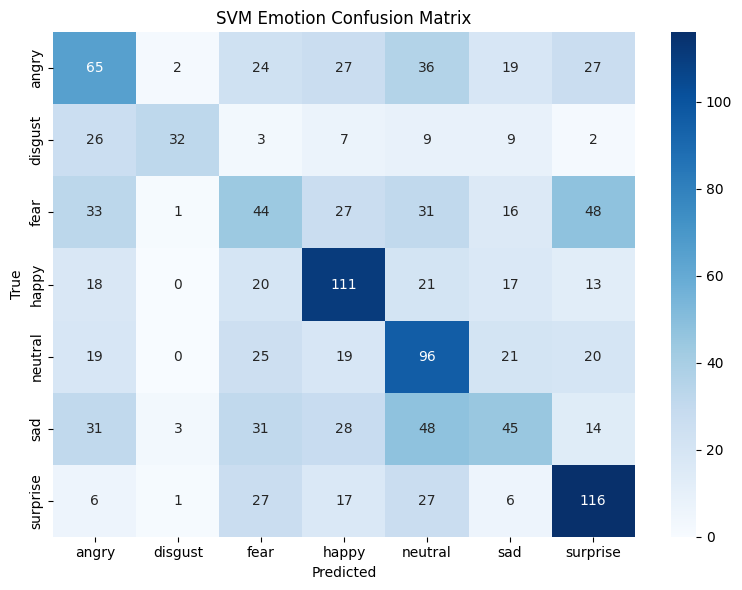

['emotion_pca.pkl']

In [16]:
import os, cv2, numpy as np
from skimage.feature import hog
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib # Import joblib to save models

EMOTIONS = ['angry','disgust','fear','happy','neutral','sad','surprise']
DATA_DIR = 'fer2013/train'

def extract_hog(img_gray):
    """Extract HOG features — the SVM's eyes."""
    features, _ = hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        visualize=True,
        block_norm='L2-Hys'
    )
    return features

X, y = [], []
for label in EMOTIONS:
    folder = os.path.join(DATA_DIR, label)
    for fname in os.listdir(folder)[:1000]:  # limit for speed
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (48, 48))
            X.append(extract_hog(img))
            y.append(label)

X = np.array(X)
y = np.array(y)

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ---- OPTIMIZATION 1: PCA to shrink feature dimensions ----
# HOG gives ~2000+ features — reduce to 200, keeps 95% variance
# RBF kernel cost is O(n_features * n_samples²), so this helps a lot
pca = PCA(n_components=200, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca  = pca.transform(X_test_s)
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.1%}")

# ---- OPTIMIZATION 2: Use LinearSVC first (100x faster than RBF) ----
# LinearSVC is O(n_samples) vs RBF SVM O(n_samples²)
# Wrap with CalibratedClassifierCV to get predict_proba() back
linear_svc = CalibratedClassifierCV(LinearSVC(C=0.1, max_iter=2000))
linear_svc.fit(X_train_pca, y_train)
y_pred_linear = linear_svc.predict(X_test_pca)
print("LinearSVC report:")
print(classification_report(y_test, y_pred_linear, target_names=le.classes_))

# ---- OPTIMIZATION 3: RBF only on PCA-reduced features ----
# Only run this if LinearSVC accuracy is too low for your needs
svm = SVC(kernel='rbf', C=1, gamma='scale', probability=True, cache_size=500)
svm.fit(X_train_pca, y_train)          # train on PCA features, not raw HOG
y_pred = svm.predict(X_test_pca)
print("RBF SVM report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix — fixed (y_pred now exists)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('SVM Emotion Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

# Save the trained model, scaler, and label encoder
joblib.dump(svm, 'emotion_svm.pkl')
joblib.dump(scaler, 'emotion_scaler.pkl')
joblib.dump(le, 'emotion_le.pkl')
joblib.dump(pca, 'emotion_pca.pkl') # Save the PCA object as well

In [11]:
# Cell: Webcam capture helper (run ONCE in Colab)
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import PIL.Image, io

def take_photo(quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = '📷 Capture';
          div.appendChild(capture);
          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();
          await new Promise((r) => capture.onclick = r);
          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getTracks().forEach(t => t.stop());
          div.remove();
          return canvas.toDataURL('image/jpeg', quality);
        }
        takePhoto(%f)
    ''' % quality)
    display(js)
    data = eval_js('takePhoto(%f)' % quality)
    binary = b64decode(data.split(',')[1])
    return PIL.Image.open(io.BytesIO(binary))

<IPython.core.display.Javascript object>

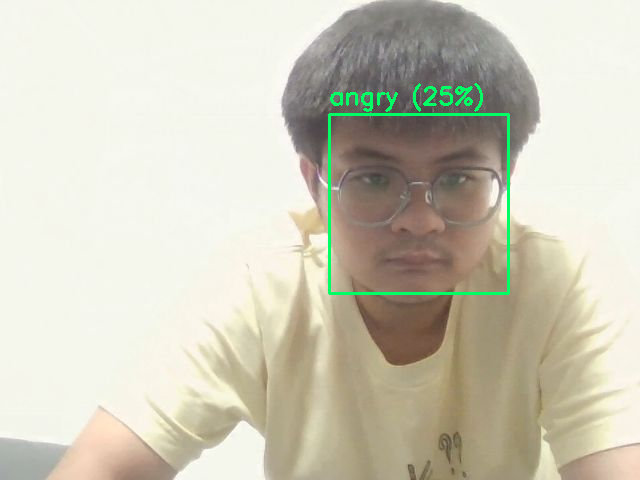

In [18]:
import numpy as np, cv2
from skimage.feature import hog
import joblib # Import joblib

# Load saved model
svm    = joblib.load('emotion_svm.pkl')
scaler = joblib.load('emotion_scaler.pkl')
le     = joblib.load('emotion_le.pkl')
pca    = joblib.load('emotion_pca.pkl') # Load the PCA object

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def predict_emotion(pil_img):
    img = np.array(pil_img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))

    for (x, y, w, h) in faces:
        roi = gray[y:y+h, x:x+w]
        roi = cv2.resize(roi, (48, 48))
        feats = hog(roi, orientations=9, pixels_per_cell=(4,4),
                    cells_per_block=(2,2), block_norm='L2-Hys').reshape(1,-1)
        feats_s = scaler.transform(feats)
        feats_pca = pca.transform(feats_s) # Apply PCA transformation
        label = le.inverse_transform(svm.predict(feats_pca))[0]
        prob   = svm.predict_proba(feats_pca).max()

        # Draw bounding box and label
        cv2.rectangle(img, (x,y), (x+w, y+h), (0,255,100), 2)
        cv2.putText(img, f"{label} ({prob:.0%})", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,100), 2)

    return PIL.Image.fromarray(img)

# Capture & predict
photo = take_photo()
result = predict_emotion(photo)
display(result)